# [문제 정의] 수락률 분석 및 문제점 도출

In [1]:
df['event_time'] = pd.to_datetime(df['time'], unit='s')

NameError: name 'pd' is not defined

In [4]:
# ---------------------------------------------------------
# [방법 1] 필터링 & 정렬 (가장 직관적인 형태)
# ---------------------------------------------------------

# 1. 우리가 관심 있는 이벤트 목록 정의
target_events = [
    'editor_run_paraphrasing',
    'run_paraphrasing',
    'editor_selected_paraphrasing',
    'selected_paraphrasing'
]

# 2. 해당 이벤트만 남기기 (Row Filtering)
filtered_df = df[df['event_name'].isin(target_events)].copy()

# 3. 보고 싶은 컬럼만 남기기 (Column Selection)
target_columns = [
    'distinct_id_event',                                # 사용자 ID
    'event_name',                                       # 이벤트명 (Run/Select)
    'llm_name',                                         # 모델명
    'maintenance',                                      # 교정 강도
    'field',                                            # 글 분야
    'total_paraphrasing_sentence_count',                # 동일 문장으로 재실행한 수(3의 배수로 측정: 3-1회 실행, 6-2회 실행)
    'response_time_seconds',                            # 소요 시간
    'event_time'                                        # timestamp
]

final_df = filtered_df[target_columns]

# apply & lambda 활용하여 3으로 나누기
col_name = 'total_paraphrasing_sentence_count'
if col_name in final_df.columns:
    # 숫자인 경우 3으로 나누고, 비어있거나(NaN) 숫자가 아니면 그대로 둠(pass)
    final_df[col_name] = final_df[col_name].apply(
        lambda x: x / 3 if pd.notnull(x) and isinstance(x, (int, float)) else x
    )

# 4. 사용자별(distinct_id_event)로 모아서 보기 좋게 정렬
# 시간 순서(timestamp)가 있다면 같이 정렬해야 흐름이 보입니다.
sort_cols = ['distinct_id_event']
if 'event_time' in df.columns:
    sort_cols.append('event_time')

final_df = final_df.sort_values(by=sort_cols)

C:\Users\yusj0\AppData\Local\Temp\ipykernel_21468\367181842.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df[col_name] = final_df[col_name].apply(


In [5]:
final_df

,distinct_id_event,event_name,llm_name,maintenance,field,total_paraphrasing_sentence_count,response_time_seconds,event_time
60489,$device:00281c0b-bc22-4113-9980-f344ac66367b,run_paraphrasing,OpenAI,moderate,marketing,NaN,3.04,2025-06-06 12:07:16
60490,$device:00281c0b-bc22-4113-9980-f344ac66367b,run_paraphrasing,OpenAI,moderate,marketing,NaN,4.05,2025-06-06 12:08:25
60491,$device:00281c0b-bc22-4113-9980-f344ac66367b,run_paraphrasing,OpenAI,moderate,marketing,NaN,3.82,2025-06-06 12:10:03
60492,$device:00281c0b-bc22-4113-9980-f344ac66367b,run_paraphrasing,OpenAI,moderate,marketing,NaN,2.87,2025-06-06 12:11:57
60493,$device:00281c0b-bc22-4113-9980-f344ac66367b,run_paraphrasing,OpenAI,moderate,marketing,NaN,4.29,2025-06-06 12:13:30
...,...,...,...,...,...,...,...,...
61241,fc4f0c45-4f59-4782-bf3a-6af6c66c07c3,run_paraphrasing,gemini-2.0-flash,moderate,none,NaN,1.18,2025-06-15 02:20:59
61242,fc4f0c45-4f59-4782-bf3a-6af6c66c07c3,run_paraphrasing,gemini-2.0-flash,moderate,none,NaN,1.51,2025-06-15 02:21:11
61243,fc4f0c45-4f59-4782-bf3a-6af6c66c07c3,run_paraphrasing,gemini-2.0-flash,moderate,none,NaN,1.52,2025-06-15 02:21:27
57696,fc4f0c45-4f59-4782-bf3a-6af6c66c07c3,run_paraphrasing,gemini-2.0-flash,strong,none,NaN,2.06,2025-06-16 15:31:45


In [8]:
final_df.to_csv('./data/merge_acceptance_final.csv', index=False)

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import platform
import seaborn as sns
sns.set_theme(style="darkgrid")
import koreanize_matplotlib

In [3]:
df = pd.read_csv('./data/merge_acceptance_final.csv')

In [8]:
df

,distinct_id_event,event_name,llm_name,maintenance,field,total_paraphrasing_sentence_count,response_time_seconds,event_time
0,$device:00281c0b-bc22-4113-9980-f344ac66367b,run_paraphrasing,OpenAI,moderate,marketing,NaN,3.04,2025-06-06 12:07:16
1,$device:00281c0b-bc22-4113-9980-f344ac66367b,run_paraphrasing,OpenAI,moderate,marketing,NaN,4.05,2025-06-06 12:08:25
2,$device:00281c0b-bc22-4113-9980-f344ac66367b,run_paraphrasing,OpenAI,moderate,marketing,NaN,3.82,2025-06-06 12:10:03
3,$device:00281c0b-bc22-4113-9980-f344ac66367b,run_paraphrasing,OpenAI,moderate,marketing,NaN,2.87,2025-06-06 12:11:57
4,$device:00281c0b-bc22-4113-9980-f344ac66367b,run_paraphrasing,OpenAI,moderate,marketing,NaN,4.29,2025-06-06 12:13:30
...,...,...,...,...,...,...,...,...
56805,fc4f0c45-4f59-4782-bf3a-6af6c66c07c3,run_paraphrasing,gemini-2.0-flash,moderate,none,NaN,1.18,2025-06-15 02:20:59
56806,fc4f0c45-4f59-4782-bf3a-6af6c66c07c3,run_paraphrasing,gemini-2.0-flash,moderate,none,NaN,1.51,2025-06-15 02:21:11
56807,fc4f0c45-4f59-4782-bf3a-6af6c66c07c3,run_paraphrasing,gemini-2.0-flash,moderate,none,NaN,1.52,2025-06-15 02:21:27
56808,fc4f0c45-4f59-4782-bf3a-6af6c66c07c3,run_paraphrasing,gemini-2.0-flash,strong,none,NaN,2.06,2025-06-16 15:31:45


In [4]:
df['maintenance'].value_counts()

maintenance
moderate    41135
strong      10099
weak         1463
Name: count, dtype: int64

In [5]:
df[df['maintenance'] == 'strong']['llm_name'].value_counts()

llm_name
gemini-2.0-flash            9444
OpenAI                        88
claude-sonnet-4-20250514       8
gpt-4.1                        4
Name: count, dtype: int64

In [6]:
df[df['maintenance'] == 'moderate']['llm_name'].value_counts()

llm_name
gemini-2.0-flash            37768
OpenAI                        620
gpt-4.1                       343
grok-3                         14
claude-sonnet-4-20250514        5
Name: count, dtype: int64

In [7]:
df[df['maintenance'] == 'weak']['llm_name'].value_counts()

llm_name
gemini-2.0-flash    1437
OpenAI                 5
Name: count, dtype: int64

In [13]:
pd.crosstab(df['llm_name'], df['field'])

field,article,customer_service,email,marketing,none,report,thesis
llm_name,,,,,,,
OpenAI,18,4,99,117,421,14,40
claude-sonnet-4-20250514,1,0,6,0,5,0,1
gemini-2.0-flash,3188,210,5505,1128,35153,1488,1977
gpt-4.1,14,1,1,3,297,2,29
grok-3,0,0,0,0,11,3,0


In [ ]:
pd.crosstab(df['llm_name'], df['maintenance'])

maintenance,moderate,strong,weak
llm_name,,,
OpenAI,620,88,5
claude-sonnet-4-20250514,5,8,0
gemini-2.0-flash,37768,9444,1437
gpt-4.1,343,4,0
grok-3,14,0,0


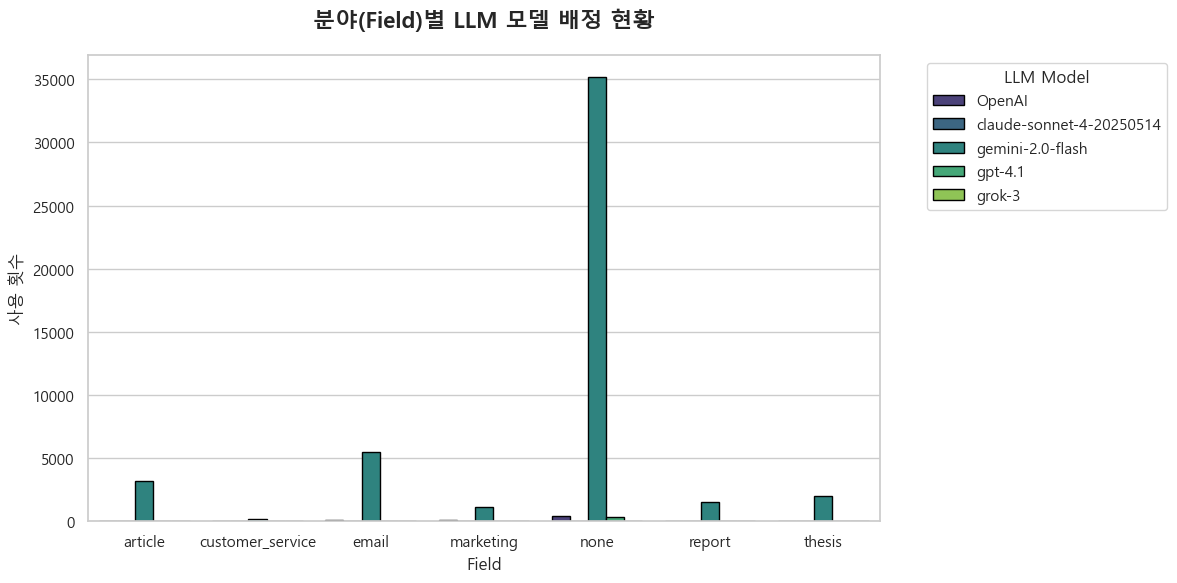

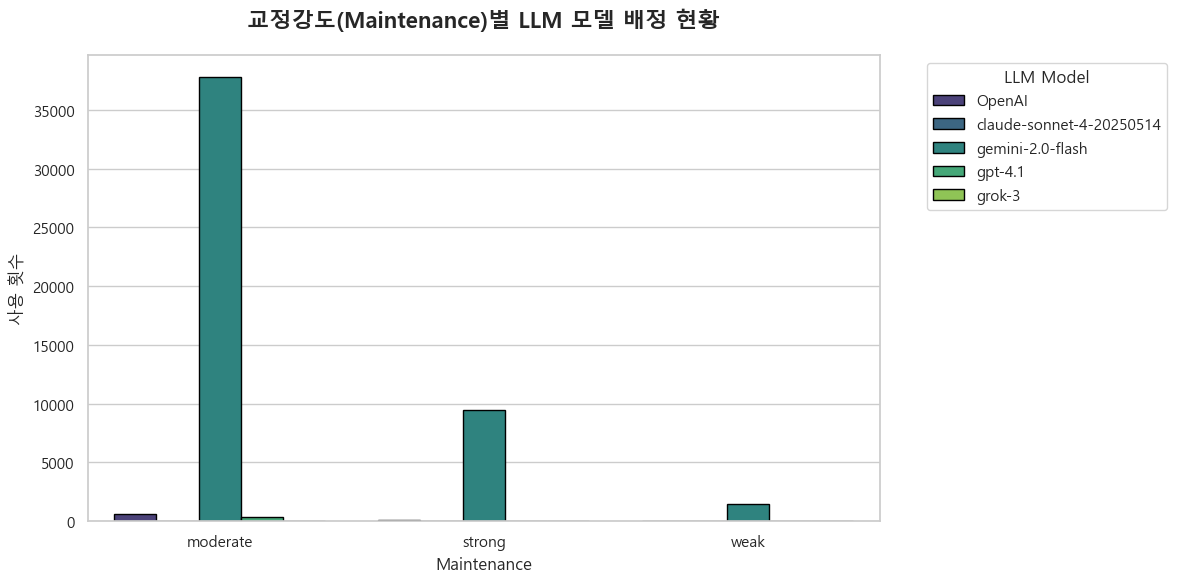

In [4]:
# ---------------------------------------------------------
# 1. 데이터 로드
# ---------------------------------------------------------
df_field = pd.read_csv('llm_name_field_crosstab.csv')
df_maintenance = pd.read_csv('llm_name_maintenance_crosstab.csv')

# ---------------------------------------------------------
# 2. 데이터 전처리 (Wide -> Long Format 변환)
# ---------------------------------------------------------
# Seaborn에서 그리기 좋게 데이터 형태를 변경합니다.
df_field_long = df_field.melt(id_vars='llm_name', var_name='Field', value_name='Count')
df_maint_long = df_maintenance.melt(id_vars='llm_name', var_name='Maintenance', value_name='Count')

# ---------------------------------------------------------
# 3. 시각화 설정 (한글 폰트 및 스타일)
# ---------------------------------------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 그래프 그리기 함수
def plot_distribution(data, x_col, hue_col, title, filename):
    plt.figure(figsize=(12, 6))

    # 막대 그래프 생성
    ax = sns.barplot(
        data=data,
        x=x_col,
        y='Count',
        hue=hue_col,
        palette='viridis',  # 색상 테마
        edgecolor='black'   # 막대 테두리
    )

    # 핵심: 데이터 불균형이 심할 경우 로그 스케일 적용 (필요시 주석 해제)
    # ax.set_yscale('log')

    # 타이틀 및 라벨 설정
    plt.title(title, fontsize=16, pad=20, fontweight='bold')
    plt.xlabel(x_col, fontsize=12)
    plt.ylabel('사용 횟수', fontsize=12)
    plt.legend(title='LLM Model', bbox_to_anchor=(1.05, 1), loc='upper left')

    # 값 표시 (숫자가 너무 겹치면 제거 가능)
    # for p in ax.patches:
    #     if p.get_height() > 0:
    #         ax.annotate(f'{int(p.get_height())}',
    #                     (p.get_x() + p.get_width() / 2., p.get_height()),
    #                     ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()
    plt.show()
    # plt.savefig(filename, dpi=300) # 저장 필요시 사용

# ---------------------------------------------------------
# 4. 그래프 출력
# ---------------------------------------------------------
# (1) Field별 LLM 분포
plot_distribution(
    df_field_long,
    x_col='Field',
    hue_col='llm_name',
    title='분야(Field)별 LLM 모델 배정 현황',
    filename='field_distribution.png'
)

# (2) 교정강도(Maintenance)별 LLM 분포
plot_distribution(
    df_maint_long,
    x_col='Maintenance',
    hue_col='llm_name',
    title='교정강도(Maintenance)별 LLM 모델 배정 현황',
    filename='maintenance_distribution.png'
)

In [6]:
df['field'].value_counts(normalize=True)

field
none                0.696510
email               0.107805
article             0.073515
thesis              0.056512
report              0.035733
marketing           0.025808
customer_service    0.004118
Name: proportion, dtype: float64

In [10]:
pd.crosstab(df['event_name'], df['total_paraphrasing_sentence_count'])

total_paraphrasing_sentence_count,1.0,2.0,3.0,4.0,5.0,6.0
event_name,,,,,,
editor_selected_paraphrasing,2566,278,92,13,4,8
selected_paraphrasing,10028,3659,0,0,0,0


In [4]:
pd.crosstab(df['field'], df['maintenance'])

maintenance,moderate,strong,weak
field,,,
article,2311,1471,92
customer_service,88,127,2
email,3725,1852,104
marketing,674,675,11
none,31796,3842,1066
report,951,913,19
thesis,1590,1219,169
